In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
import sb_bond_functions as ba
import MDAnalysis as mda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from statsmodels.stats.diagnostic import lilliefors

In [120]:
reference_struc = 'centered_active.gro' 
trajectory = ['test.xtc'] 

In [131]:
all_pairs, current_pairs, combined_coords, n_mainchain_residues, pvalue_df = ba.compute_com_contacts(trajectory, reference_struc, 
                        batch_size=100, stride=1, 
                        mc_contact_threshold=8.0, sc_contact_threshold=8.0, 
                        mc_sc_contact_threshold=8.0, variance_percentile=75, pvalue_threshold=None,
                        n_jobs=1)

test.xtc: 100%|██████████| 251/251 [00:00<00:00, 343.94it/s]


Mainchain-Mainchain pairs: 544446
Sidechain-Sidechain pairs: 544446
Mainchain-Sidechain pairs: 1089936


Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:05<00:00, 922.66it/s] 


MC-MC pairs after contact filter: 7,381


Stage 1: Contact Filter:   0%|          | 0/5445 [00:00<?, ?it/s]/wrk/romiromi/work/bond_analysis/bondflow/salt_bridge_analysis/sb_bond_functions.py:173: RuntimeWarning: All-NaN slice encountered
  min_distances = np.nanmin(batch_distances, axis=0)
Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:05<00:00, 954.56it/s] 


SC-SC pairs after contact filter: 3,925


Stage 1: Contact Filter: 100%|██████████| 10900/10900 [00:11<00:00, 923.82it/s]


MC-SC pairs after contact filter: 9,735
Total pairs after Stage 1 (all classes): 21,041


Stage 2: Variance Filter: 100%|██████████| 211/211 [00:00<00:00, 750.30it/s]


Pairs after variance filter: 5,261
Pairs after distribution filter: 5,261


In [122]:
# Create a distance dataframe to look at salt bridge distances 
# and their variance across the trajectory
model = mda.Universe(reference_struc, trajectory)
protein_residues = model.select_atoms("protein").residues
df = ba.compute_residue_pair_distances(combined_coords, current_pairs, n_mainchain_residues, protein_residues)
print(df.head())

                       pair_name bond_type  idx_i  idx_j   frame_0   frame_1  \
0  ILE94_692(MC)_GLU432_1030(MC)     MC-MC    692   1030  7.921215  8.258822   
1    GLN95_693(MC)_GLN97_695(MC)     MC-MC    693    695  6.193592  5.762156   
2  ASN310_908(MC)_ARG252_850(SC)     MC-SC    908   1894  5.171237  5.283185   
3  ASN310_908(MC)_TRP247_845(SC)     MC-SC    908   1889  8.050961  8.711424   
4  ASN309_907(MC)_GLN312_910(SC)     MC-SC    907   1954  8.804933  8.936366   

    frame_2   frame_3   frame_4   frame_5  ...  frame_243  frame_244  \
0  8.550856  8.968790  8.534949  8.740013  ...   6.637681   6.395753   
1  5.925293  6.338339  5.841439  5.912912  ...   6.196516   6.120581   
2  4.834864  5.133040  5.839412  4.661614  ...   4.764718   4.581632   
3  7.589614  8.768583  8.883612  7.742987  ...   7.459066   7.399374   
4  8.397434  8.614017  9.039531  8.986036  ...  10.366857  10.099370   

   frame_245  frame_246  frame_247  frame_248  frame_249  frame_250  \
0   6.582726   

In [123]:

def differs_from_norm_distribution(
    combined_coords,
    current_pairs,
    pvalue_threshold=None,
):


    results = []

    for (i, j) in current_pairs:

        coords_i = combined_coords[:, i, :]
        coords_j = combined_coords[:, j, :]

        distances = np.linalg.norm(coords_i - coords_j, axis=1)
        distances = distances[~np.isnan(distances)]


        stat, p_value = lilliefors(distances, dist="norm")

        results.append((i, j, stat, p_value))

    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results, columns=[
        "pair_i",
        "pair_j",
        "stat",
        "p_values",
    ])

    results_df = results_df.sort_values("p_values", ascending=True)

    # If threshold provided → filter
    if pvalue_threshold is not None:
        filtered_df = results_df[results_df["p_values"] <= pvalue_threshold]
    else:
        filtered_df = results_df

    # Convert back to pair list (same format as current_pairs)
    filtered_pairs = list(zip(filtered_df["pair_i"], filtered_df["pair_j"]))

    return filtered_pairs, results_df.reset_index(drop=True)


In [124]:
# Extra filter to look at pairs that differ from normal distribution of distances across the trajectory
current_pairs, norm_stats_df = differs_from_norm_distribution(
    combined_coords=combined_coords,
    current_pairs=current_pairs,
)

In [125]:
print(norm_stats_df.head())

   pair_i  pair_j      stat  p_values
0     701    1743  0.134064     0.001
1     694    1715  0.093272     0.001
2     694    1717  0.100229     0.001
3     694    1737  0.112214     0.001
4     694    1738  0.135451     0.001


In [126]:
# Removes duplicates based on resname and resnum!!!
unique_pairs = ba.remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues) 
print(f"Original pairs: {len(current_pairs)}")
print(f"Unique pairs:   {len(unique_pairs)}")

Original pairs: 21041
Unique pairs:   10197


In [127]:
# Search for salt bridges in the current pairs
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, current_pairs, distance_threshold=5.0)
print(binary_contact_map.shape)

print(distance_map.shape)

(233, 251)
(233, 251)


In [128]:
# Create sorted distance dataframe to look at salt bridge distances 
# and their variance across the trajectory/trajectories
dist_df, sb_names, std_df = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)

In [129]:
print(dist_df.head())

Salt bridge  LYS51_GLU48  ASP269_ARG271  GLU407_LYS378  ASP73_LYS75  \
0               3.985601       4.245869       3.876313     8.935426   
1               3.941506       4.130144       5.280495     7.345657   
2               6.269331       3.856976       3.687565     9.013930   
3               6.378443       5.322020       5.178752     9.721452   
4               5.129006       4.778552       3.331952     9.062594   

Salt bridge  LYS174_GLU246  GLU475_ARG525  GLU403_LYS114  GLU17_LYS13  \
0                 3.892861      10.544607       5.801428     4.346198   
1                 5.803315      10.192869       5.688401     4.018025   
2                 9.835293       5.010681       7.270126     3.933160   
3                 8.788840       6.039095       7.548992     4.500556   
4                 7.752556       4.169444       7.659425     6.608699   

Salt bridge  GLU541_ARG540  GLU390_ARG393  ...  GLU435_LYS71  ARG540_ASP542  \
0                 4.076227       5.968794  ...     10.7

/var/data/python/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


<Axes: >

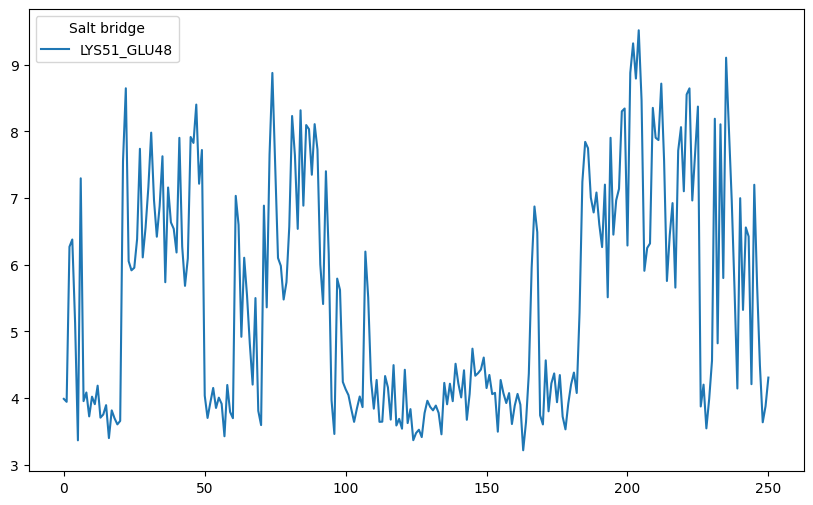

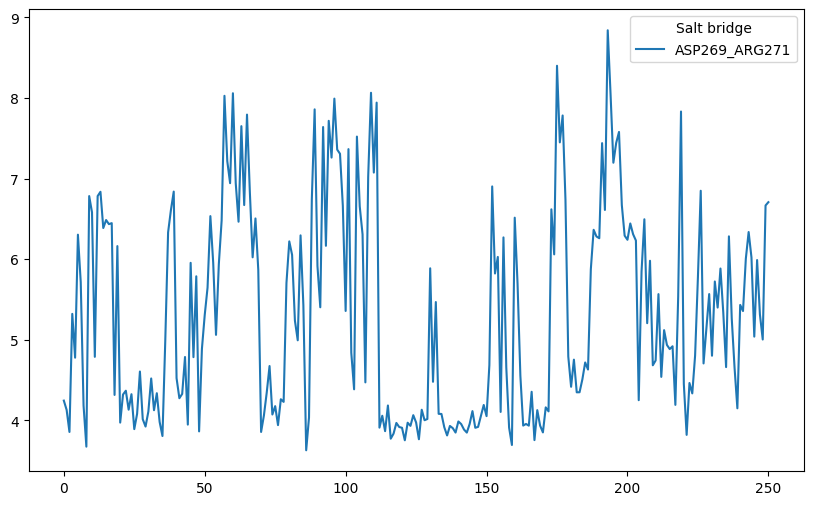

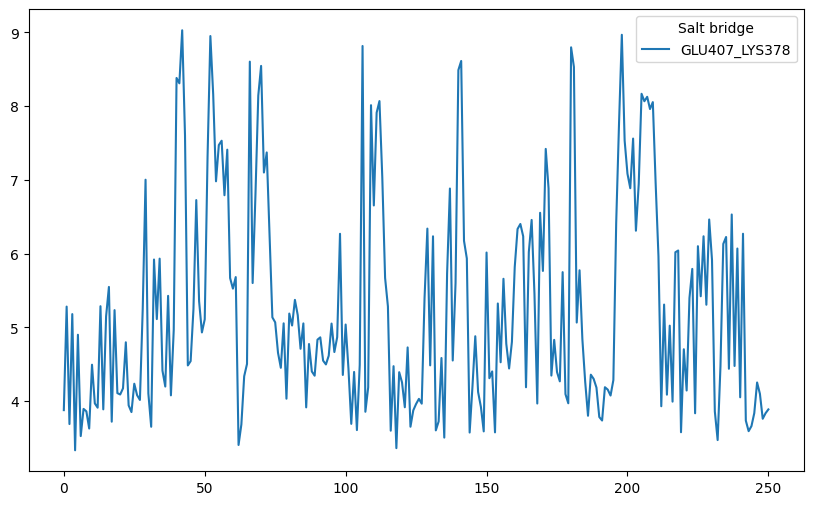

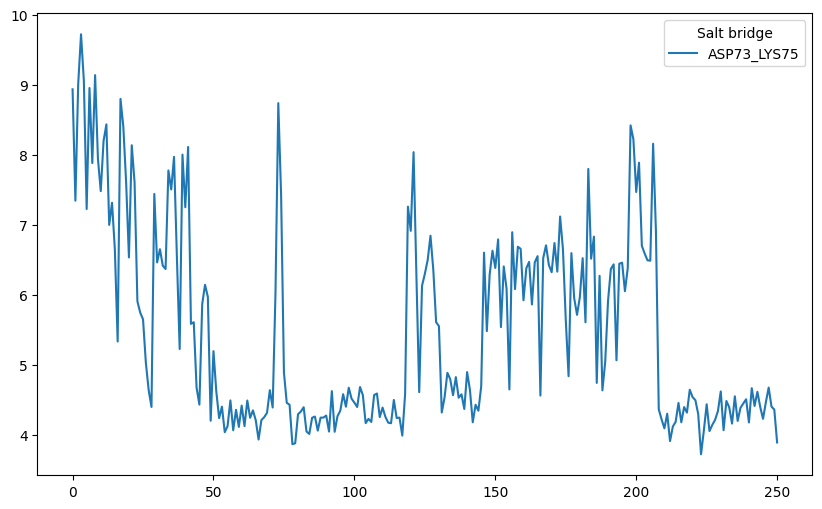

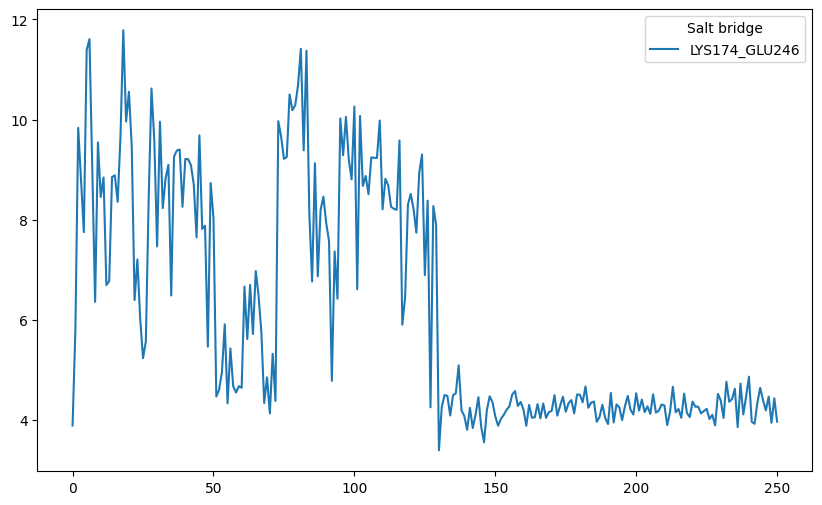

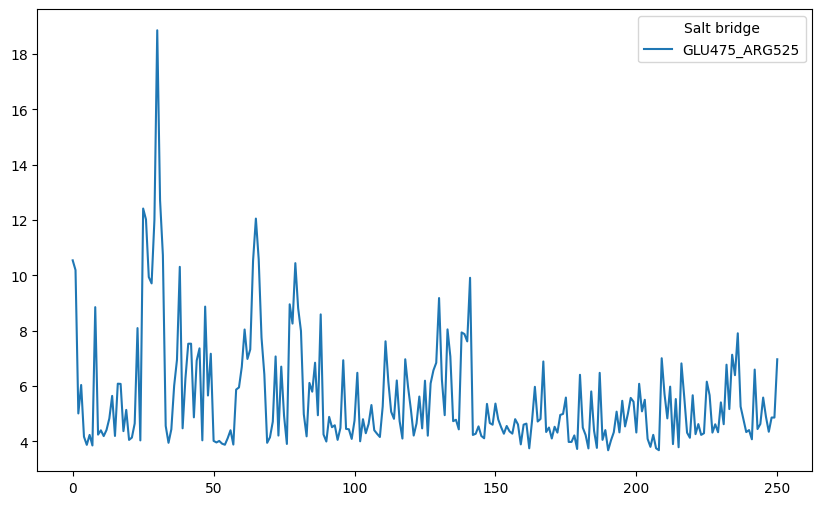

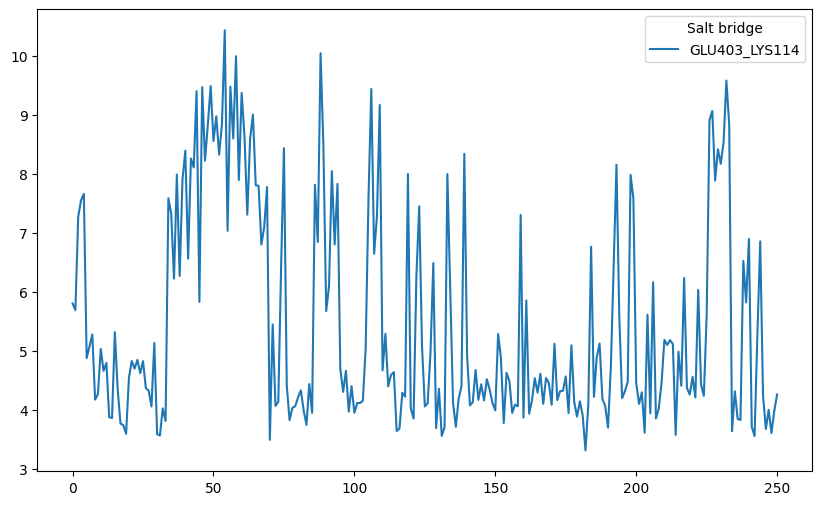

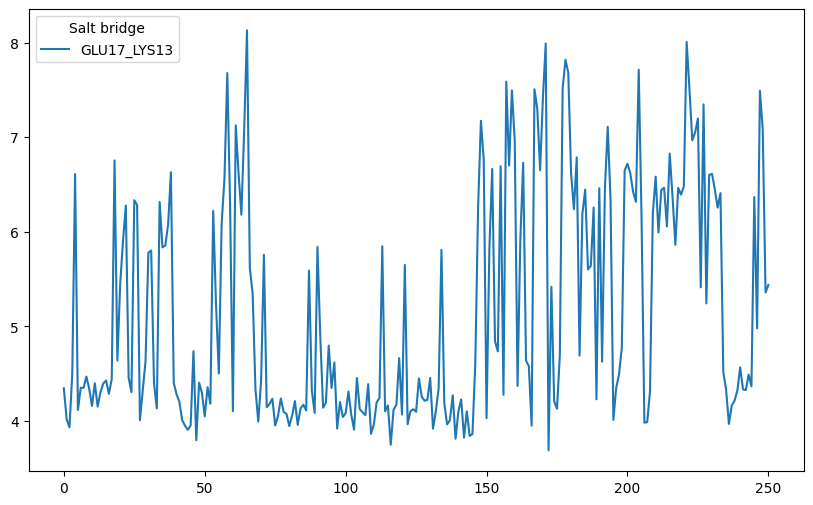

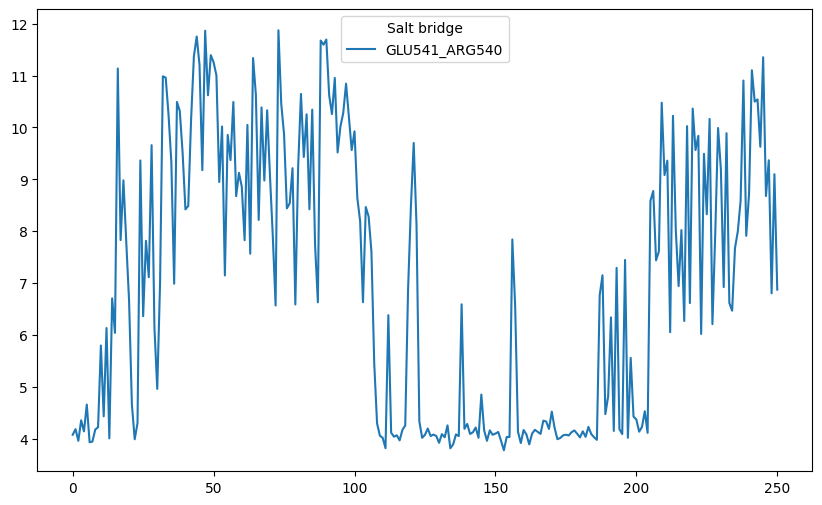

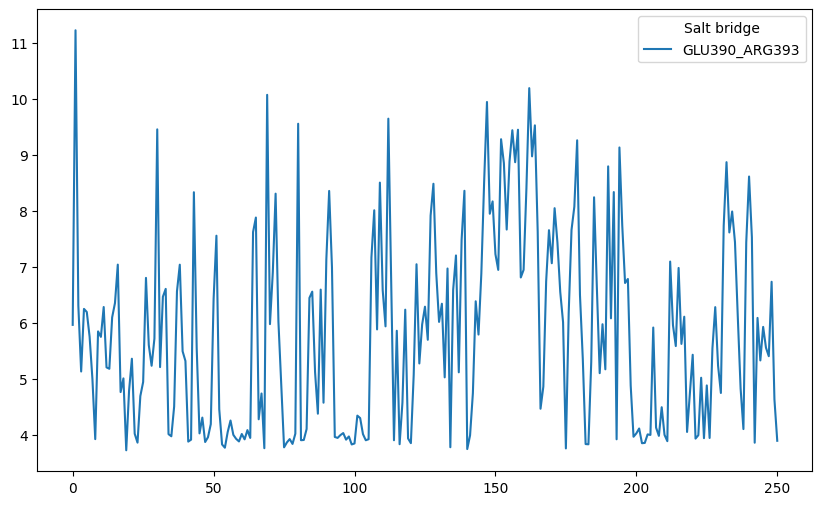

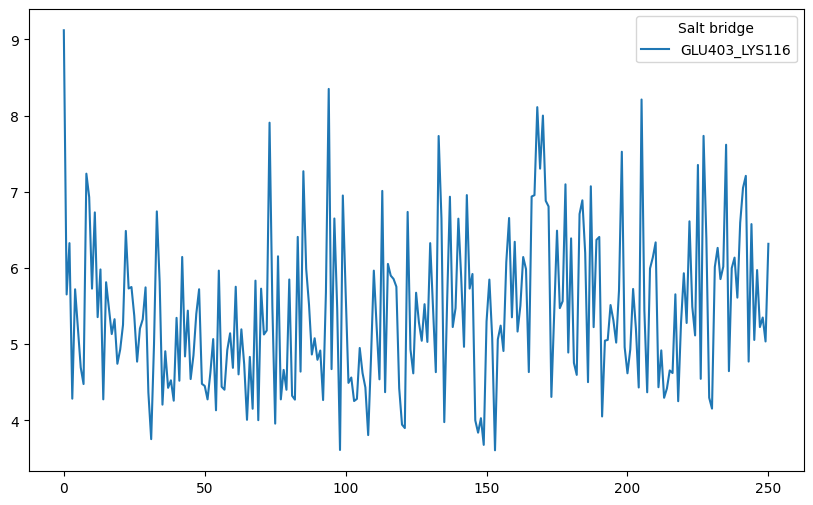

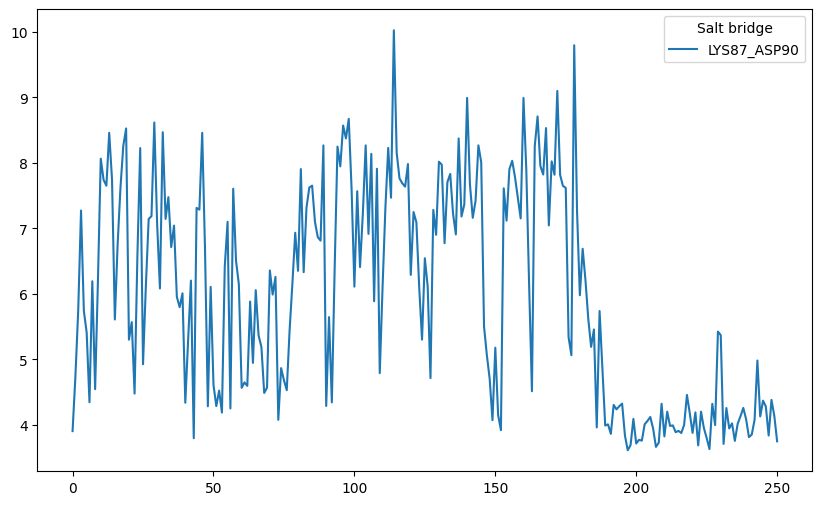

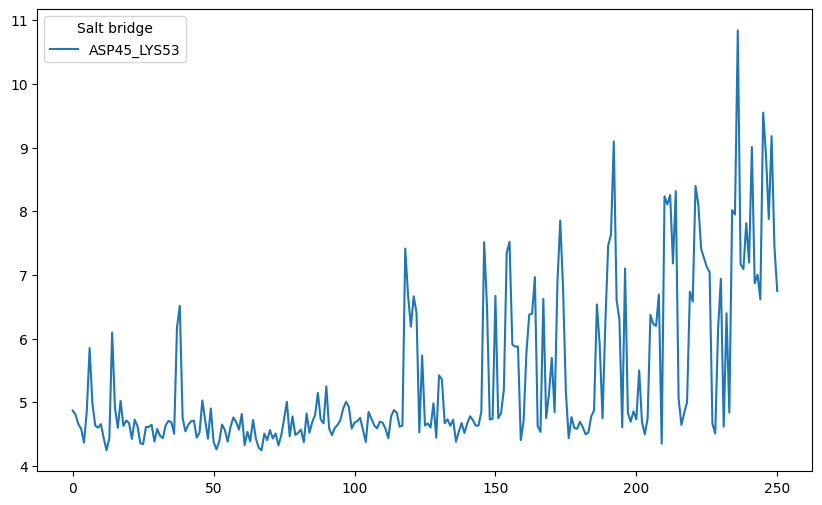

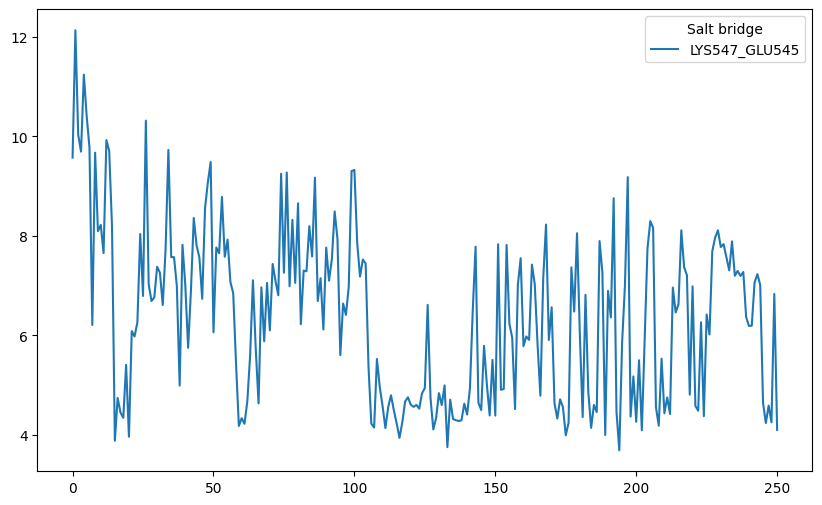

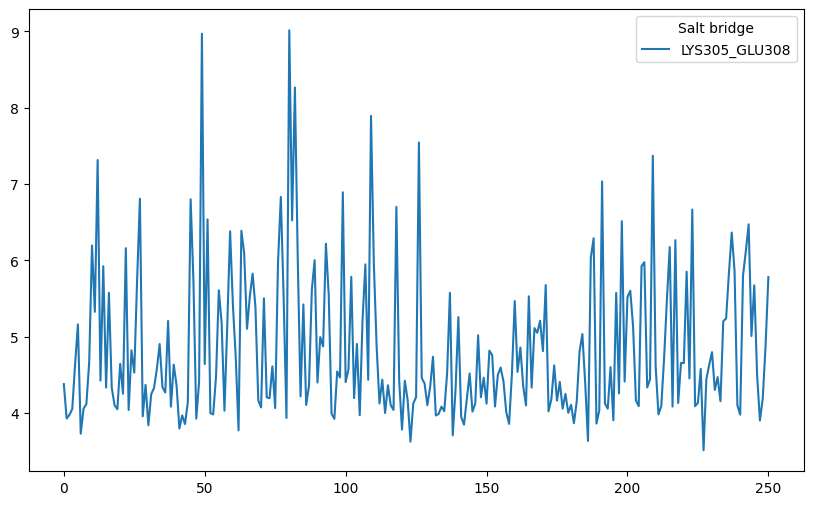

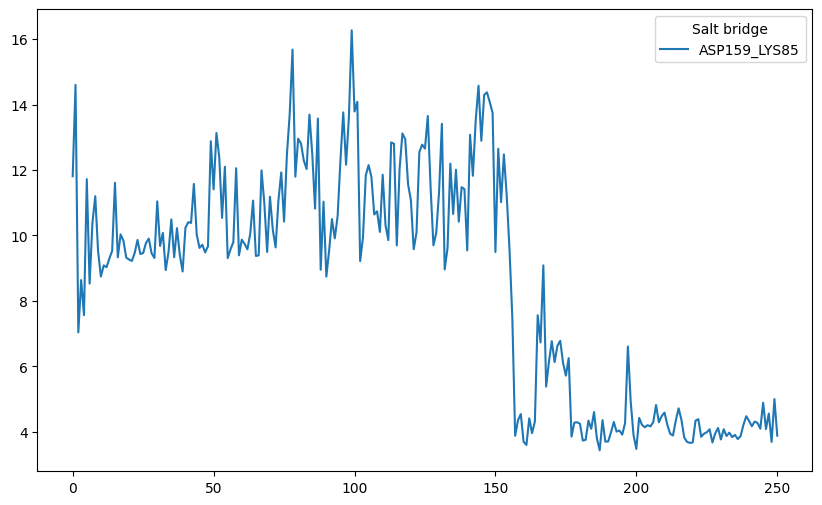

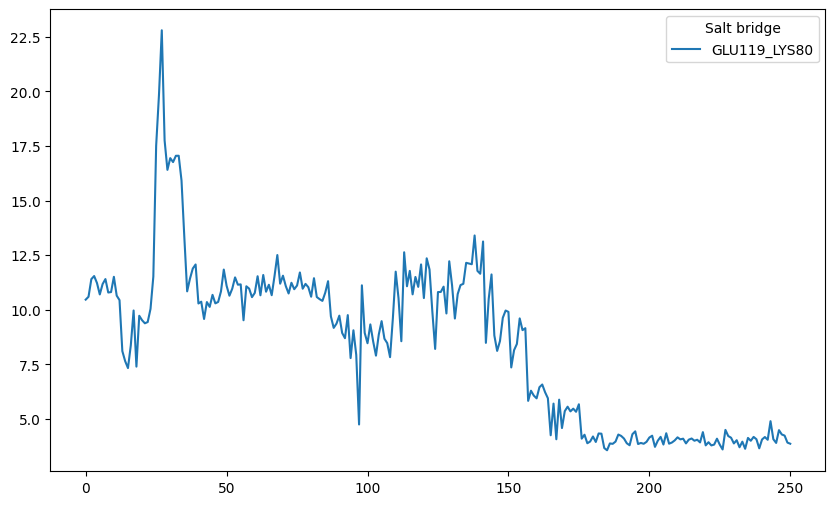

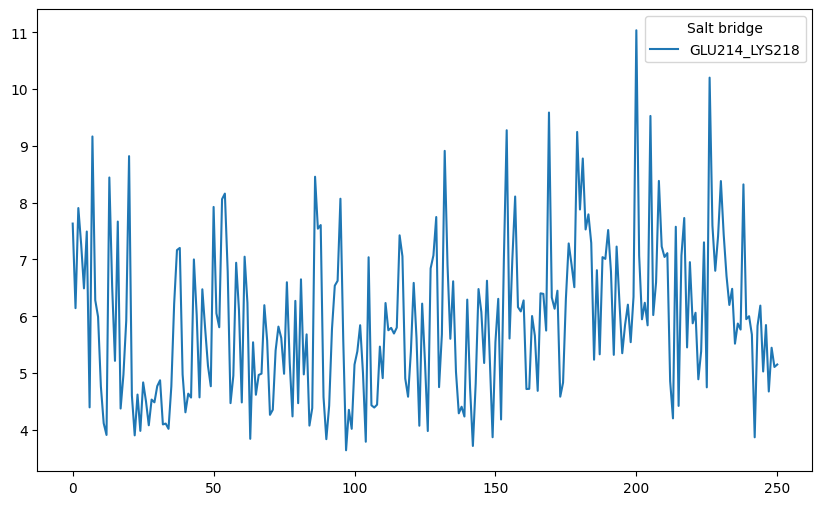

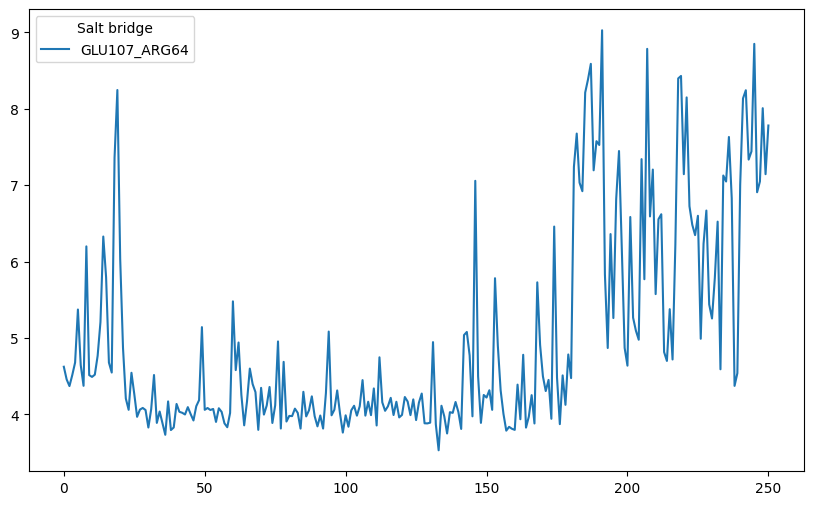

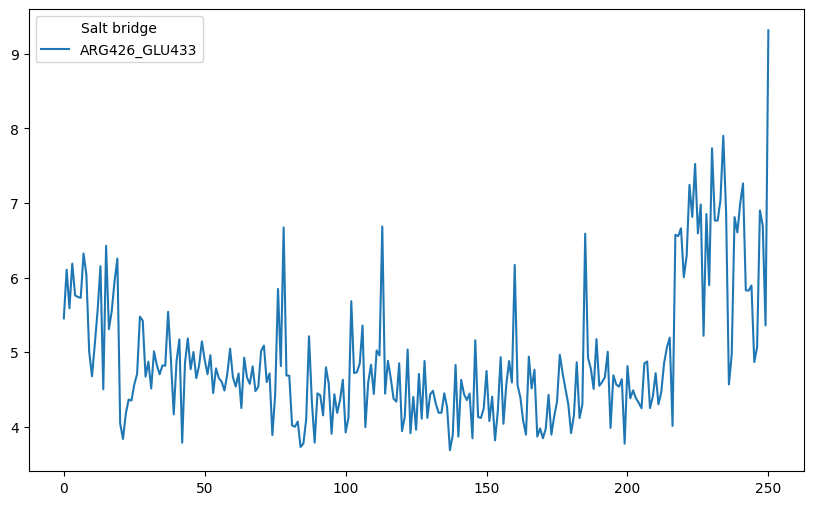

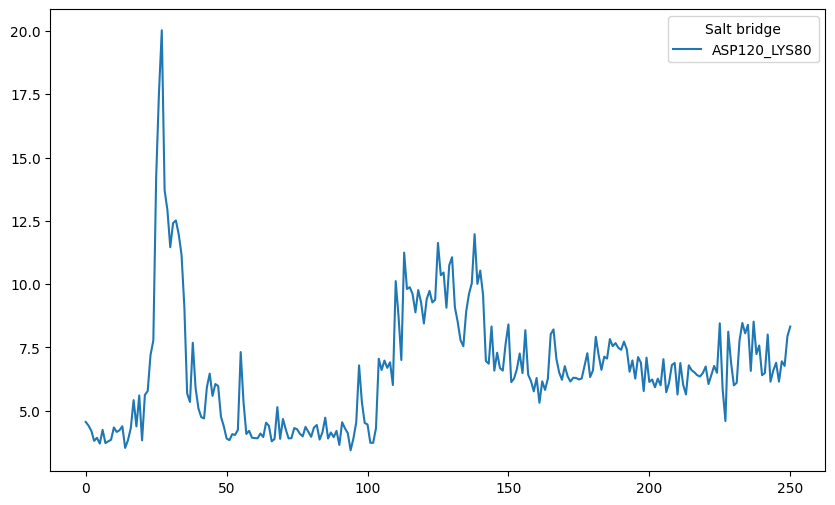

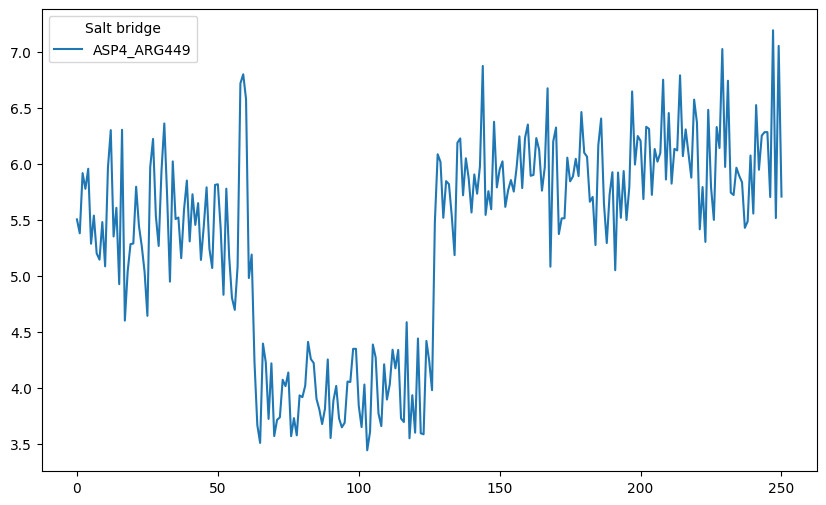

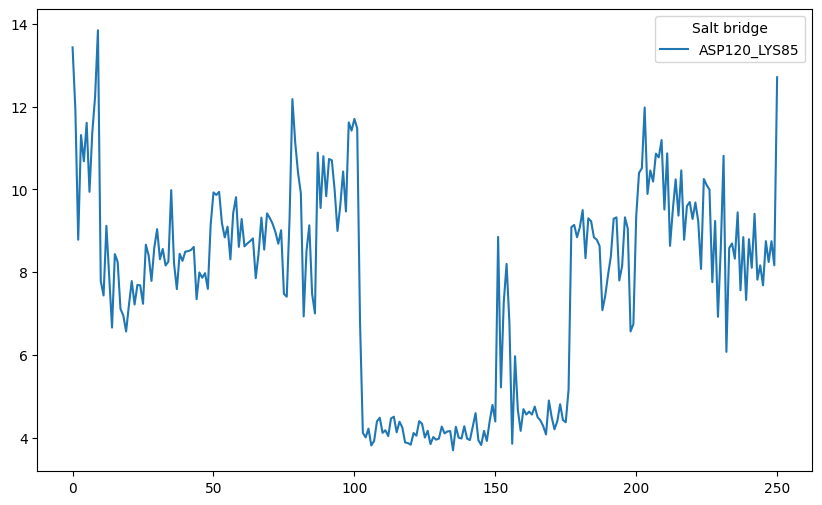

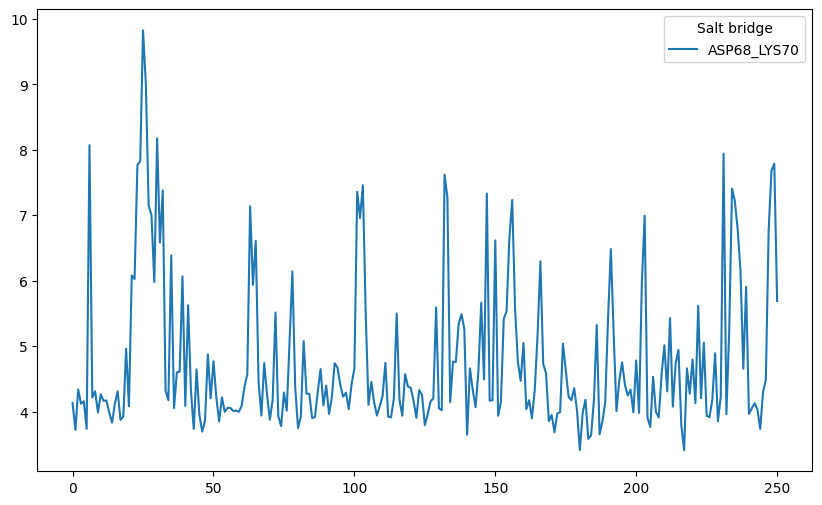

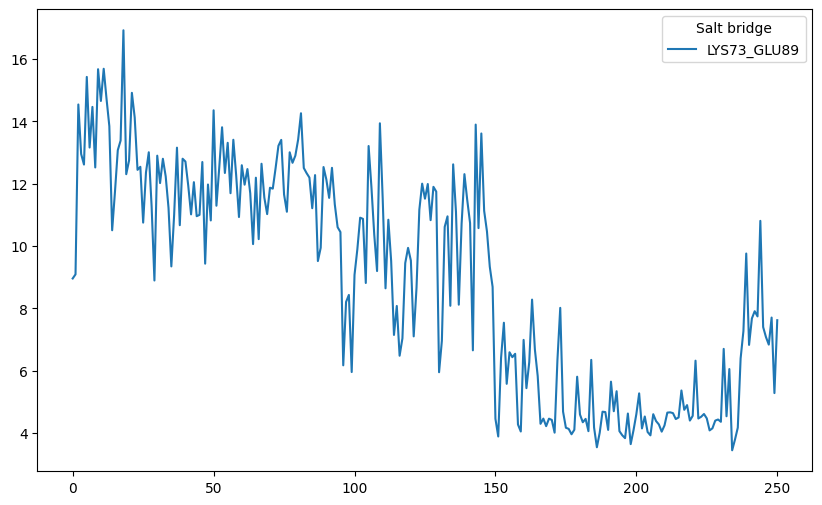

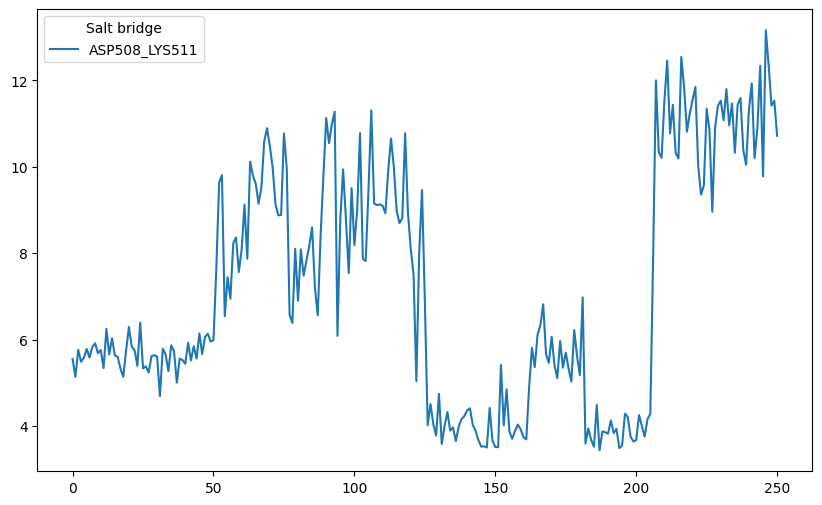

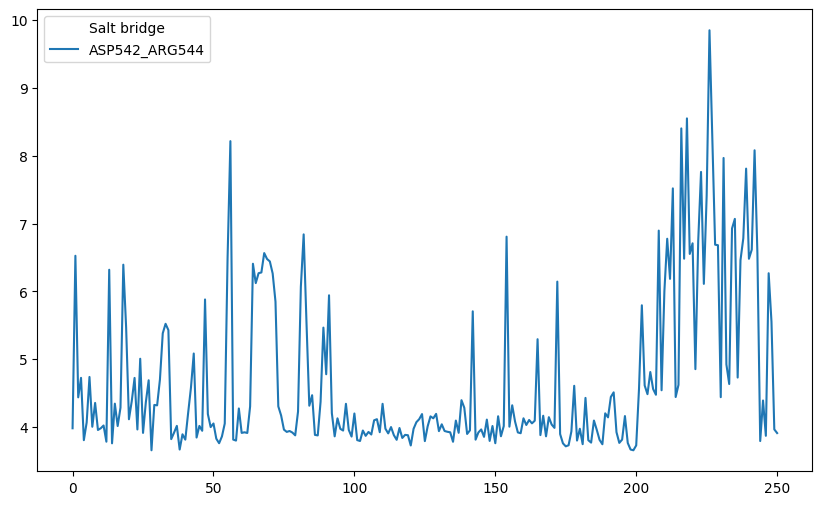

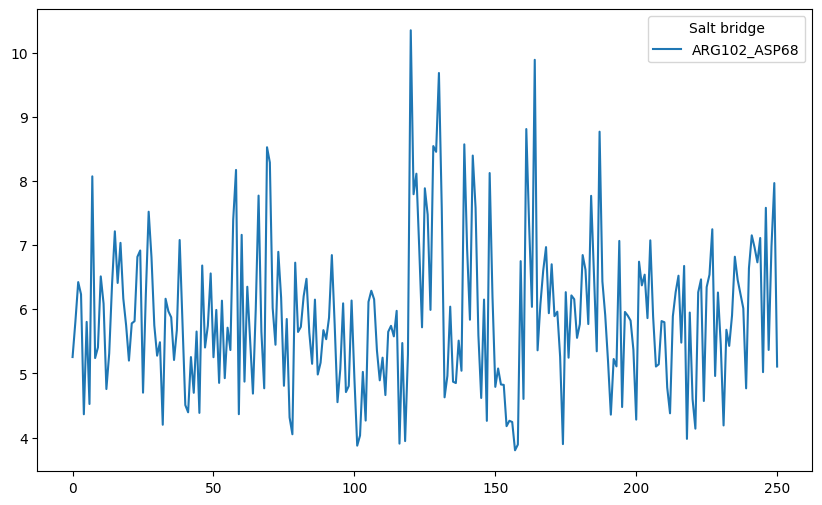

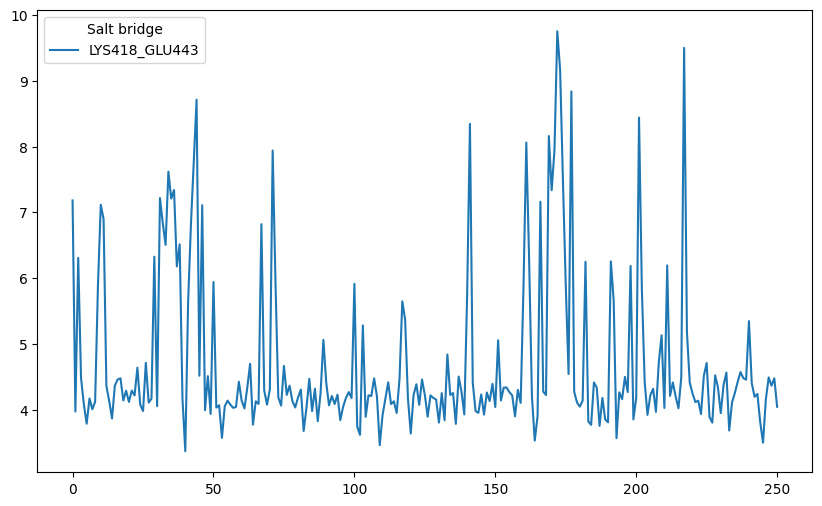

In [130]:
df2 = dist_df
sb_names = sb_names

df2.plot.line(y=[f'{sb_names[0]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[1]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[2]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[3]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[4]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[5]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[6]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[7]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[8]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[9]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[10]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[11]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[12]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[13]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[14]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[15]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[16]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[17]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[18]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[19]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[20]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[21]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[22]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[23]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[24]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[25]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[26]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[27]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[28]}'],  figsize=(10,6))